<a href="https://colab.research.google.com/github/adilamaan20/cint_learners/blob/main/Assignment_3_VAE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Assignment Objective

In this assignment, you will build a **Variational Autoencoder (VAE)** using Keras.  
The VAE will learn a compressed probabilistic latent representation of MNIST images and generate new handwritten digit-like images by sampling from the latent space.


## Task 1: Import Required Libraries

In this section, we import TensorFlow, Keras layers, NumPy, and Matplotlib.

In [4]:

# Task 1: Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Task 2: Load and Preprocess the MNIST Dataset

MNIST contains grayscale images of handwritten digits from 0 to 9.

Each image has size:

```text
28 x 28 pixels
```

For the VAE, we normalize pixel values to the range `[0, 1]` and flatten each image into a vector of size `784`.

In [5]:
# Task 2: Load and Preprocess the MNIST Dataset

# Load MNIST dataset from Keras
# x_train, x_test contain images
# y_train, y_test contain digit labels
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Convert pixel values from integers to float
# Normalize from range [0, 255] to [0, 1]
# This helps the neural network train more smoothly
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Each MNIST image is 28 x 28 pixels
# Flatten each image into a 784-dimensional vector
original_dim = 28 * 28

# Reshape training images from (60000, 28, 28) to (60000, 784)
x_train_flat = x_train.reshape((x_train.shape[0], original_dim))

# Reshape testing images from (10000, 28, 28) to (10000, 784)
x_test_flat = x_test.reshape((x_test.shape[0], original_dim))

# Print shapes to verify preprocessing
print("Training data shape:", x_train_flat.shape)
print("Testing data shape:", x_test_flat.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


## Task 3: Visualize Sample MNIST Images

Before building the model, let us look at a few sample images from the dataset.

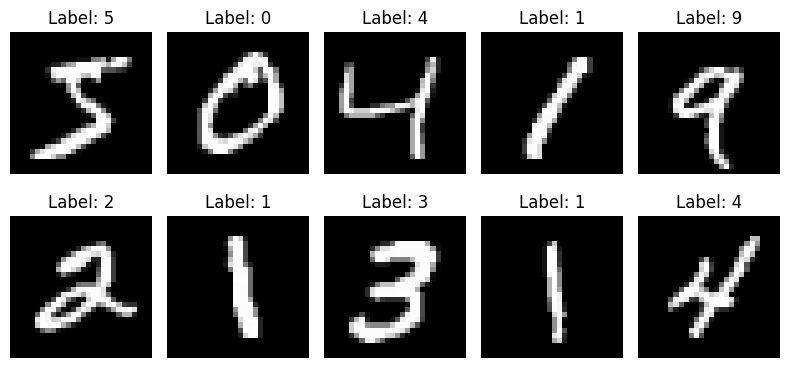

In [6]:
# Task 3: Visualize Sample MNIST Images

# Create a figure to display sample images
plt.figure(figsize=(8, 4))

# Display first 10 training images
for i in range(10):

    # Arrange images in 2 rows and 5 columns
    plt.subplot(2, 5, i + 1)

    # Show the image in grayscale
    plt.imshow(x_train[i], cmap="gray")

    # Show the true label of the digit
    plt.title(f"Label: {y_train[i]}")

    # Hide axis numbers for cleaner visualization
    plt.axis("off")

# Adjust spacing between images
plt.tight_layout()

# Display the plot
plt.show()

## Task 4: Set Hyperparameters

For this assignment, we use a **2-dimensional latent space** so that we can visualize the learned representation.

You may experiment later with larger latent dimensions such as 8, 16, or 32.

In [7]:
# Task 4: Set Hyperparameters

# Input dimension is 784 because each image is flattened from 28 x 28
input_dim = 784

# Hidden layer size used in both encoder and decoder
hidden_dim = 256

# Latent space dimension is 2 so we can visualize it later
latent_dim = 2

# Number of samples processed at one time during training
batch_size = 128

# Number of full passes through the training dataset
epochs = 20

# Learning rate controls how fast the model updates weights
learning_rate = 0.001

## Task 5: Define the Sampling Layer

A Variational Autoencoder does not directly learn one fixed latent vector.

Instead, the encoder learns:

- `z_mean`: the mean of the latent distribution
- `z_log_var`: the log variance of the latent distribution

The sampling layer applies the **reparameterization trick**:

```text
z = mean + standard deviation × random noise
```

This allows the model to sample from the latent distribution while still supporting backpropagation.

In [8]:
# Task 5: Define the Sampling Layer

# VAE does not directly output one fixed latent vector
# It outputs z_mean and z_log_var, then samples z from them
class Sampling(layers.Layer):
    """Uses z_mean and z_log_var to sample latent vector z."""

    def call(self, inputs):

        # Separate the inputs into mean and log variance
        z_mean, z_log_var = inputs

        # Get batch size dynamically
        batch = tf.shape(z_mean)[0]

        # Get latent dimension dynamically
        dim = tf.shape(z_mean)[1]

        # Generate random noise from standard normal distribution
        epsilon = tf.random.normal(shape=(batch, dim))

        # Reparameterization trick:
        # z = mean + standard deviation * random noise
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        # Return sampled latent vector
        return z

## Task 6: Build the Encoder

The encoder maps each input image into a latent probability distribution.

Architecture:

```text
Input image vector → Dense layer → z_mean and z_log_var → Sampling layer → z
```

In [9]:
# Task 6: Build the Encoder

# Encoder input receives flattened image vector of size 784
encoder_inputs = keras.Input(shape=(input_dim,), name="encoder_input")

# Dense hidden layer learns features from the input image
x = layers.Dense(hidden_dim, activation="relu")(encoder_inputs)

# z_mean represents the center of the latent distribution
z_mean = layers.Dense(latent_dim, name="z_mean")(x)

# z_log_var represents the log variance of the latent distribution
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling layer generates actual latent vector z
z = Sampling()([z_mean, z_log_var])

# Encoder model takes image input and outputs z_mean, z_log_var, and z
encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

# Display encoder architecture
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

## Task 7: Build the Decoder

The decoder maps a sampled latent vector back into an image.

Architecture:

```text
Latent vector z → Dense layer → Reconstructed image vector
```

The output layer uses `sigmoid` activation because MNIST pixel values are normalized between 0 and 1.

In [10]:
# Task 7: Build the Decoder

# Decoder input receives latent vector z of size 2
latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")

# Dense hidden layer expands latent representation
x = layers.Dense(hidden_dim, activation="relu")(latent_inputs)

# Output layer reconstructs image vector of size 784
# Sigmoid is used because pixel values are between 0 and 1
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)

# Decoder model takes latent vector and outputs reconstructed image
decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

# Display decoder architecture
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

## Task 8: Define the VAE Model

A VAE requires a custom training step because the loss has two components:

1. **Reconstruction loss**  
   Measures how close the reconstructed image is to the original image.

2. **KL divergence loss**  
   Regularizes the latent distribution so that it stays close to a standard normal distribution.

The total loss is:

```text
Total Loss = Reconstruction Loss + KL Divergence Loss
```

In [11]:
# Task 8: Define the VAE Model

# VAE combines encoder and decoder
# It also uses custom training because VAE loss has two parts:
# 1. Reconstruction loss
# 2. KL divergence loss
class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):

        # Initialize parent Keras Model class
        super().__init__(**kwargs)

        # Store encoder model
        self.encoder = encoder

        # Store decoder model
        self.decoder = decoder

        # Track total loss during training
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")

        # Track reconstruction loss separately
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")

        # Track KL divergence loss separately
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):

        # Keras uses this list to reset metrics after each epoch
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):

        # Keras may pass data as tuple
        # Since VAE is unsupervised, we only need input images
        if isinstance(data, tuple):
            data = data[0]

        # GradientTape records operations for backpropagation
        with tf.GradientTape() as tape:

            # Encoder maps input image to latent distribution
            z_mean, z_log_var, z = self.encoder(data)

            # Decoder reconstructs image from sampled latent vector
            reconstruction = self.decoder(z)

            # Reconstruction loss measures difference between original and reconstructed image
            # Binary cross-entropy is suitable because pixels are normalized between 0 and 1
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1
                )
            )

            # KL divergence loss keeps latent distribution close to standard normal distribution
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total VAE loss is reconstruction loss plus KL loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients of total loss with respect to trainable weights
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Apply gradients to update model weights
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update total loss tracker
        self.total_loss_tracker.update_state(total_loss)

        # Update reconstruction loss tracker
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)

        # Update KL loss tracker
        self.kl_loss_tracker.update_state(kl_loss)

        # Return losses so they appear during training
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):

        # Encode input image into latent variables
        z_mean, z_log_var, z = self.encoder(inputs)

        # Decode latent vector into reconstructed image
        reconstruction = self.decoder(z)

        # Return reconstructed image
        return reconstruction

## Task 9: Compile and Train the VAE

Now we compile the model using the Adam optimizer and train it on MNIST.

Because this is an unsupervised generative model, we only use the images, not the class labels.

In [12]:
# Task 9: Compile and Train the VAE

# Create VAE model using encoder and decoder
vae = VAE(encoder, decoder)

# Compile model with Adam optimizer
# Loss is included for Keras compatibility, but custom train_step computes actual VAE loss
vae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss=keras.losses.BinaryCrossentropy()
)

# Train the VAE using only images
# Labels are not used because VAE is an unsupervised generative model
history = vae.fit(
    x_train_flat,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - kl_loss: 2.6702 - loss: 36.5805 - reconstruction_loss: 33.9104
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 1.9422 - loss: 30.8989 - reconstruction_loss: 28.9568
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 2.2156 - loss: 30.3145 - reconstruction_loss: 28.0989
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 2.3401 - loss: 30.0594 - reconstruction_loss: 27.7193
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 2.4298 - loss: 29.9024 - reconstruction_loss: 27.4727
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.5028 - loss: 29.7785 - reconstruction_loss: 27.2757
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 2.5471 - loss: 29.6549 - reconstruction_loss: 27.1078
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 2.6179 - loss: 29.5673 - reconstruction_loss: 26.9493
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - 

## Task 10: Plot Training Loss

The total loss should generally decrease during training.

The loss includes both reconstruction loss and KL divergence loss.

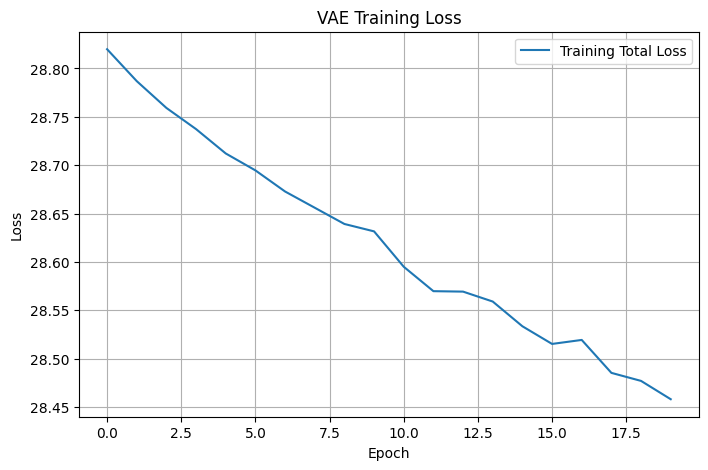

In [12]:
# Task 10: Plot Training Loss

# Create a figure for loss curve
plt.figure(figsize=(8, 5))

# Plot total training loss across epochs
plt.plot(history.history["loss"], label="Training Total Loss")

# Plot validation loss only if it exists in history
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Validation Total Loss")

# Label x-axis
plt.xlabel("Epoch")

# Label y-axis
plt.ylabel("Loss")

# Add plot title
plt.title("VAE Training Loss")

# Show legend
plt.legend()

# Add grid for readability
plt.grid(True)

# Display the plot
plt.show()

## Task 11: Reconstruct MNIST Images

In this section, we pass test images through the VAE and compare the original images with the reconstructed images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


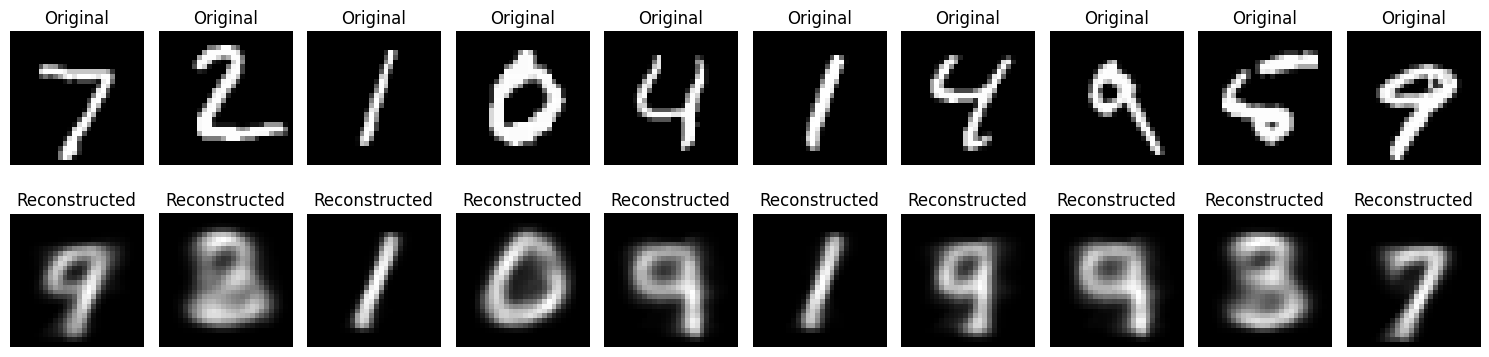

In [13]:
# Task 11: Reconstruct MNIST Images

def plot_reconstructions(model, x_data, n=10):

    # Select first n test images
    test_images = x_data[:n]

    # Pass test images through VAE to get reconstructed images
    reconstructed = model.predict(test_images)

    # Create figure with original images on first row and reconstructed images on second row
    plt.figure(figsize=(15, 4))

    for i in range(n):

        # Plot original image
        plt.subplot(2, n, i + 1)

        # Reshape flattened vector back to 28 x 28 image
        plt.imshow(test_images[i].reshape(28, 28), cmap="gray")

        # Title for original image
        plt.title("Original")

        # Hide axis
        plt.axis("off")

        # Plot reconstructed image
        plt.subplot(2, n, i + 1 + n)

        # Reshape reconstructed vector back to 28 x 28 image
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")

        # Title for reconstructed image
        plt.title("Reconstructed")

        # Hide axis
        plt.axis("off")

    # Adjust spacing
    plt.tight_layout()

    # Display images
    plt.show()


# Call function to compare original and reconstructed test images
plot_reconstructions(vae, x_test_flat, n=10)

## Task 12: Generate New Digits from Random Latent Vectors

The main goal of a generative model is to create new samples.

Here, we sample random points from the latent space and pass them through the decoder.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


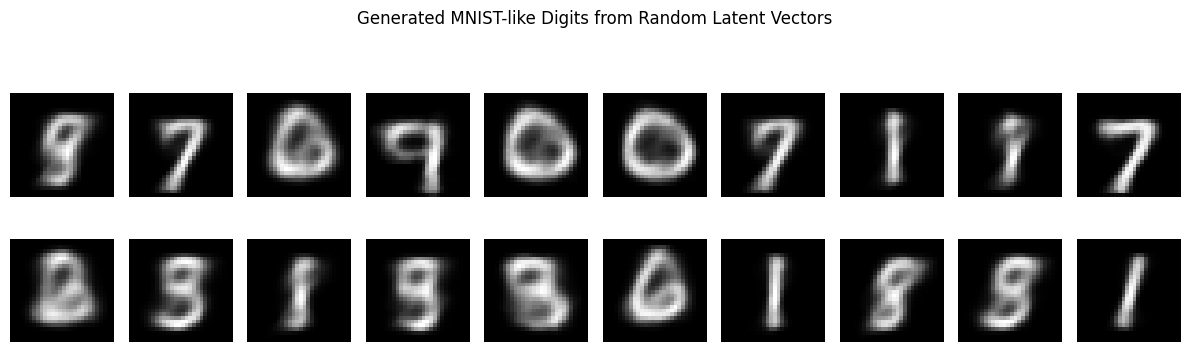

In [14]:
# Task 12: Generate New Digits from Random Latent Vectors

def generate_random_digits(decoder, latent_dim=2, n=20):

    # Sample random points from standard normal distribution
    # Each point is a latent vector
    random_latent_vectors = np.random.normal(size=(n, latent_dim))

    # Decode random latent vectors into generated images
    generated_images = decoder.predict(random_latent_vectors)

    # Create figure to show generated digits
    plt.figure(figsize=(12, 4))

    for i in range(n):

        # Arrange generated images in 2 rows
        plt.subplot(2, n // 2, i + 1)

        # Reshape generated vector back to 28 x 28 image
        plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")

        # Hide axis
        plt.axis("off")

    # Add overall title
    plt.suptitle("Generated MNIST-like Digits from Random Latent Vectors")

    # Adjust spacing
    plt.tight_layout()

    # Display generated images
    plt.show()


# Generate 20 new MNIST-like digits
generate_random_digits(decoder, latent_dim=latent_dim, n=20)

## Task 13: Visualize the 2D Latent Space

Because we used a 2-dimensional latent space, we can plot the encoded test images.

Each point represents an image in the learned latent space.  
The color represents the true digit label.

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


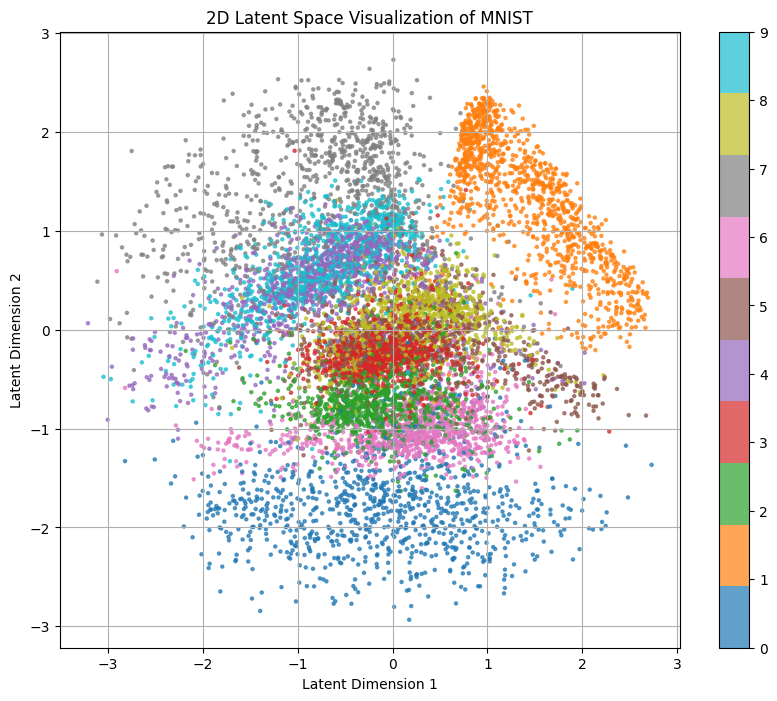

In [15]:
# Task 13: Visualize the 2D Latent Space

# Encode all test images into latent space
# We use z_mean because it represents the center of each image's latent distribution
z_mean_test, z_log_var_test, z_test = encoder.predict(
    x_test_flat,
    batch_size=128
)

# Create figure for 2D scatter plot
plt.figure(figsize=(10, 8))

# Plot each image as a point in 2D latent space
# Color represents the true digit label
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)

# Add colorbar showing digit labels 0 to 9
plt.colorbar(scatter, ticks=range(10))

# Label x-axis as first latent dimension
plt.xlabel("Latent Dimension 1")

# Label y-axis as second latent dimension
plt.ylabel("Latent Dimension 2")

# Add plot title
plt.title("2D Latent Space Visualization of MNIST")

# Add grid for readability
plt.grid(True)

# Display latent space plot
plt.show()